# Classification NN — Customer Churn (Pass/Fail-style binary problem)

Follows `neural_network_design_pocket_reference.md` section by section.

**Section 1 — Define the Problem**: predict `Exited` (1 = customer churned, 0 = stayed) from customer attributes.
- Output neurons: 1
- Output activation: Sigmoid
- Loss: Binary Cross-Entropy

This mirrors the pocket reference's pass/fail example — just with real data instead of 3 toy features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

## Data Preparation (prerequisite before Section 2)

Not covered in the pocket reference, but needed before the network can see real data:
- `RowNumber` / `CustomerId` / `Surname` carry no predictive signal — drop them.
- `Geography` / `Gender` are text — one-hot encode so every feature is numeric (`drop_first=True` avoids the dummy-variable trap).
- Split train/test **before** scaling, and fit the scaler on train only — fitting on test data would leak test-set information into training.

In [2]:
# TODO: load the CSV into a DataFrame
df = pd.read_csv("Churn_Modelling.csv")

# TODO: drop RowNumber, CustomerId, Surname
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

# TODO: one-hot encode Geography and Gender
df = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True)

# TODO: sanity check the result
df.shape
df.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [3]:
X = df.drop(columns=["Exited"]).values.astype(np.float32)
y = df["Exited"].values.astype(np.float32)

rng = np.random.default_rng(seed=42)
shuffled_idx = rng.permutation(len(X))

split_point = int(0.8 * len(X))
train_idx, test_idx = shuffled_idx[:split_point], shuffled_idx[split_point:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

mean, std = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train).reshape(-1, 1)
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test).reshape(-1, 1)

print(X_train_t.shape, y_train_t.shape)

torch.Size([8000, 11]) torch.Size([8000, 1])


## Sections 2–4 — Architecture, Weight Init, Activation

- **Section 2**: input layer size = number of features after encoding (`X_train_t.shape[1]`, not the toy example's 3). Hidden layer size is your choice — try 16 first.
- **Section 3**: hidden layer feeds ReLU → **He/Kaiming init**. Output layer feeds Sigmoid → **Xavier init**.
- **Section 4**: ReLU on the hidden layer, Sigmoid on the output (binary classification → probability).

Fill in each `# TODO` using the exact call shown in the comment above it.

In [4]:
class ClassificationNet(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.hidden = nn.Linear(in_features=in_features,out_features=16)
        self.output = nn.Linear(in_features=16,out_features=1)
        self.relu = nn.ReLU()
        self.out_activation = nn.Sigmoid()

        # TODO — Section 9: dropout layer, p = fraction of neurons to randomly drop
        self.drop = nn.Dropout(p=0.2)

        nn.init.kaiming_normal_(self.hidden.weight, nonlinearity='relu')
        nn.init.xavier_uniform_(self.output.weight)

    def forward(self, x):
        x = self.relu(self.hidden(x))

        # TODO — Section 9: apply dropout here, after ReLU, before the output layer
        x = self.drop(x)

        x = self.out_activation(self.output(x))
        return x


## Section 5 — Forward Propagation

Every layer does the same two-step dance, in order:
1. **Linear step**: `z = weighted sum of inputs + bias` — this is exactly what calling `self.hidden(x)` does internally, using the weights `nn.Linear` created.
2. **Activation step**: apply the non-linearity to `z` — `self.relu(...)` or `self.out_activation(...)`.

For this network, data flows: `input → hidden (Linear) → ReLU → output (Linear) → Sigmoid → prediction`.

The `forward()` method just chains the layers you already built in `__init__`, in that order, and returns the final result (`y_hat`) — a probability between 0 and 1 that a customer churns.

## Section 6 — Choose the Loss Function

**Loss** = error for one data point. **Cost** = average error across all points (what actually drives a weight update).

Binary classification + Sigmoid output → **Binary Cross-Entropy** is the matching loss (see the pocket reference's "Right Combination" table). It's declared **outside** the class, in the training script — not a layer, not part of the architecture.

In [5]:
# TODO — instantiate the model and the loss function:
model = ClassificationNet(in_features=X_train_t.shape[1])
criterion = nn.BCELoss()

## Section 7 — Backpropagation & Chain Rule

Goal: find `∂Loss/∂w` for every weight, then correct it — `w_new = w_old - η · ∂L/∂w_old`.

You don't hand-derive this — PyTorch's **autograd** does it automatically. Once `loss` is computed from a forward pass, calling `.backward()` on it walks the computation graph backward and fills in `.grad` for every parameter.

This is also where Sections 3 (init) and 4 (activation) pay off: ReLU + He init avoids the vanishing-gradient problem that all-Sigmoid deep stacks suffer from — worth remembering if training stalls later.

A single forward + loss + backward pass, on the full training set (no batching yet — that's Section 10):

In [6]:
# TODO — forward pass: get predictions from the model
y_hat = model(X_train_t)

# TODO — compute the loss between predictions and true labels
loss = criterion(y_hat, y_train_t)

# TODO — backpropagate: populate .grad on every parameter
loss.backward()

# TODO — inspect it: print(loss.item())
print(loss.item())

0.6779395937919617


## Section 8 — Choose an Optimizer

Each optimizer exists to fix the previous one's flaw: Batch GD (too heavy) → SGD (too noisy) → Mini-batch SGD (still noisy) → Momentum (fixed LR) → Adagrad (LR decays too hard) → RMSprop → **Adam** (momentum + adaptive rate, combined).

Adam is the default choice for most modern networks — same declaration regardless of problem type.

In [7]:
# TODO — declare the optimizer, pointing it at the model's parameters:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Section 9 — Regularize with Dropout

Overfitting: training accuracy high, test accuracy much lower — the model memorized training data instead of learning a generalizable pattern.

Dropout randomly deactivates a fraction `p` of neurons on every training pass — no neuron can become "load-bearing." At inference (`model.eval()`), dropout switches off and every neuron contributes.

This adds a new layer to the **existing** `ClassificationNet` cell above — scroll back up and add these two `# TODO`s to it (don't create a new class):
- In `__init__`, after `self.out_activation`: `self.drop = nn.Dropout(p=0.2)`
- In `forward()`, right after the ReLU step, before the output layer: `x = self.drop(x)`

I've added the TODO markers directly into that cell for you.

## Section 10 — Train the Network

- **Epoch** = one full pass through the entire training dataset.
- **Batch size** = how many data points are used per weight-update step.
- **Iteration** = one weight-update step. `iterations per epoch = dataset size / batch size`.

`DataLoader` handles splitting `X_train_t`/`y_train_t` into batches and reshuffling each epoch. This replaces the single full-batch pass from Section 7 with proper mini-batch training.

Two cells: first wrap the tensors into a batchable dataset, then run the loop that ties every previous section together — forward (5) → loss (6) → backward (7) → optimizer step (8), with dropout (9) active via `model.train()`.

In [8]:
# TODO — wrap the training tensors into a Dataset, then a DataLoader:
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

## Watching the Optimizer Work — Instrumenting the Loop

Three signals, recorded once per epoch (using the last batch of that epoch):
- **Loss** — is the cost actually going down?
- **Hidden-layer weight norm** (`model.hidden.weight.norm()`) — the overall magnitude of that layer's weights. Watching it move over epochs is literally "how much is the optimizer adjusting the weights."
- **Hidden-layer gradient norm** (`model.hidden.weight.grad.norm()`) — how much backprop signal is reaching that layer. Ties directly back to Section 7: if this collapses toward 0 while loss stalls, that's vanishing gradient, made visible instead of theoretical.

All three are recorded **after the inner batch loop ends**, once per epoch: `.grad` from the last batch's `backward()` call is still sitting there (only `zero_grad()` clears it, and that happens at the start of the *next* iteration), so grabbing it there gives one gradient reading per epoch, aligned with the one loss/weight reading per epoch — three lists of equal length, ready to plot against each other.

I've added the three empty lists and the three `.append()` TODOs into your existing training-loop cell below — everything else in that cell is unchanged.

In [9]:
# TODO — define how many epochs to train for (try 50 first):
num_epochs = 50

# TODO — three empty lists to record history into, before the loop starts:
train_losses = []
hidden_weight_norms = []
hidden_grad_norms = []

# TODO — the training loop, with history tracking and per-batch logging:

for epoch in range(num_epochs):
    model.train()                           #dropout active
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        optimizer.zero_grad()
        y_hat = model(x_batch)
        loss = criterion(y_hat, y_batch)
        loss.backward()
        optimizer.step()
        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(train_loader)-1:03d}"
                f" | Train Loss: {loss.item():.2f}")
    #once per epoch, using the LAST batch of that epoch:
    #(.grad from the last backward() is still there — zero_grad() hasn't run yet)
    train_losses.append(loss.item())
    hidden_weight_norms.append(model.hidden.weight.norm().item())
    hidden_grad_norms.append(model.hidden.weight.grad.norm().item())

Epoch: 001/050 | Batch 000/249 | Train Loss: 0.72
Epoch: 001/050 | Batch 001/249 | Train Loss: 0.76
Epoch: 001/050 | Batch 002/249 | Train Loss: 0.49
Epoch: 001/050 | Batch 003/249 | Train Loss: 0.74
Epoch: 001/050 | Batch 004/249 | Train Loss: 0.80
Epoch: 001/050 | Batch 005/249 | Train Loss: 0.66
Epoch: 001/050 | Batch 006/249 | Train Loss: 0.50
Epoch: 001/050 | Batch 007/249 | Train Loss: 0.80
Epoch: 001/050 | Batch 008/249 | Train Loss: 0.54
Epoch: 001/050 | Batch 009/249 | Train Loss: 0.52
Epoch: 001/050 | Batch 010/249 | Train Loss: 0.63
Epoch: 001/050 | Batch 011/249 | Train Loss: 0.66
Epoch: 001/050 | Batch 012/249 | Train Loss: 0.68
Epoch: 001/050 | Batch 013/249 | Train Loss: 0.63
Epoch: 001/050 | Batch 014/249 | Train Loss: 0.65
Epoch: 001/050 | Batch 015/249 | Train Loss: 0.69
Epoch: 001/050 | Batch 016/249 | Train Loss: 0.68
Epoch: 001/050 | Batch 017/249 | Train Loss: 0.61
Epoch: 001/050 | Batch 018/249 | Train Loss: 0.59
Epoch: 001/050 | Batch 019/249 | Train Loss: 0.62


## Plotting the Three Curves

Three separate line charts, not one shared axis — loss, weight norm, and gradient norm live on very different scales, so overlaying them on one y-axis (or a dual-axis trick) would distort all three. Run this after training finishes.

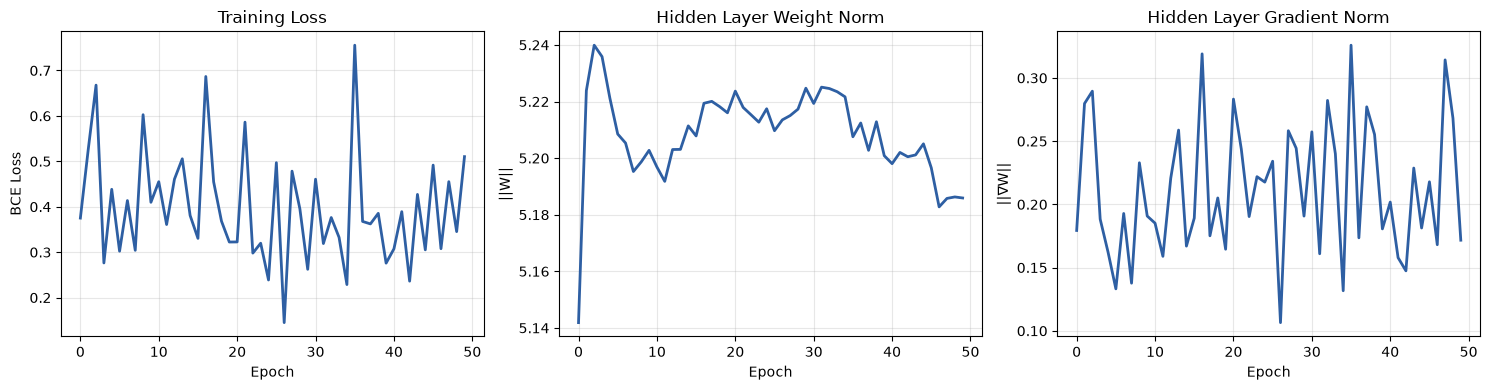

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_losses, color="#2E5FA3", linewidth=2)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")

axes[1].plot(hidden_weight_norms, color="#2E5FA3", linewidth=2)
axes[1].set_title("Hidden Layer Weight Norm")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("||W||")

axes[2].plot(hidden_grad_norms, color="#2E5FA3", linewidth=2)
axes[2].set_title("Hidden Layer Gradient Norm")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("||∇W||")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluating on the Test Set

Steps:
1. Check class balance first — churn datasets are usually imbalanced, and if `Exited` skews heavily toward 0, accuracy alone becomes a misleading metric (a model that always predicts "stays" can still score high accuracy).
2. Switch to `model.eval()` and wrap inference in `torch.no_grad()` — dropout turns off, and we don't need gradients for inference (ties back to Section 9).
3. Threshold the Sigmoid output at 0.5 to get hard 0/1 predictions.
4. Build the confusion matrix by hand (TP/FP/TN/FN), then derive accuracy, precision, recall, F1 from it — no sklearn, consistent with the manual split/scaling earlier.

Precision/recall matter more than accuracy here: precision asks "of the customers we flagged as churning, how many actually did," recall asks "of the customers who actually churned, how many did we catch" — the business tradeoff between the two depends on whether false alarms or missed churners are more costly.

In [11]:
df["Exited"].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [12]:
model.eval()
with torch.no_grad():
    y_pred_proba = model(X_test_t)
y_pred = (y_pred_proba >= 0.5).float()

TP = ((y_pred == 1) & (y_test_t == 1)).sum().item()
FP = ((y_pred == 1) & (y_test_t == 0)).sum().item()
TN = ((y_pred == 0) & (y_test_t == 0)).sum().item()
FN = ((y_pred == 0) & (y_test_t == 1)).sum().item()

accuracy = (TP + TN) / (TP + FP + TN + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"Confusion matrix:\n  TP={TP}  FP={FP}\n  FN={FN}  TN={TN}")

Accuracy:  0.8500
Precision: 0.8691
Recall:    0.3764
F1:        0.5253
Confusion matrix:
  TP=166  FP=25
  FN=275  TN=1534


## Sanity Check — Is the Loss Actually Noisy, or Is Our Measurement Noisy?

Everything above still stands untouched. This trains a **fresh** `ClassificationNet` + optimizer (new variable names, `_check` suffix) — reusing your already-trained `model` here would corrupt the evaluation and loss-landscape cells above, which depend on its final trained weights.

Same data, same architecture, same hyperparameters (`lr=0.001`, `batch_size=32`, `num_epochs=50`) — the only difference is we track **two** loss signals per epoch instead of one:
- **Last-batch loss** — what the original cell already tracks (one noisy sample per epoch).
- **Epoch-average loss** — the mean loss across all ~250 batches in that epoch, a much less noisy signal.

If the epoch-average line trends down smoothly, the "no real downward trend" read was a last-batch sampling artifact, not an optimization problem. If it's still bouncing around even averaged, that's real evidence for the LR-too-high theory.

In [13]:
model_check = ClassificationNet(in_features=X_train_t.shape[1])
optimizer_check = torch.optim.Adam(model_check.parameters(), lr=0.001)

last_batch_losses = []
epoch_avg_losses = []

for epoch in range(num_epochs):
    model_check.train()
    batch_losses = []
    for x_batch, y_batch in train_loader:
        optimizer_check.zero_grad()
        y_hat = model_check(x_batch)
        loss = criterion(y_hat, y_batch)
        loss.backward()
        optimizer_check.step()
        batch_losses.append(loss.item())
    last_batch_losses.append(batch_losses[-1])
    epoch_avg_losses.append(sum(batch_losses) / len(batch_losses))

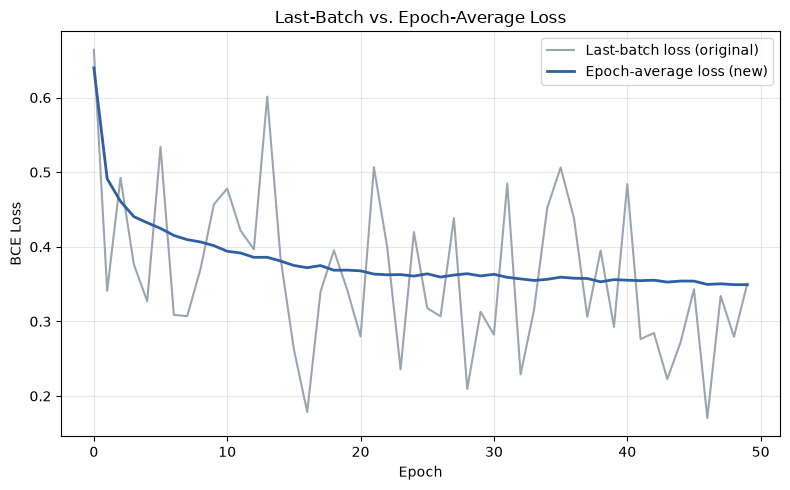

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(last_batch_losses, color="#9AA5B1", linewidth=1.5, label="Last-batch loss (original)")
ax.plot(epoch_avg_losses, color="#2E5FA3", linewidth=2, label="Epoch-average loss (new)")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("Last-Batch vs. Epoch-Average Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()